In [24]:
import math
import os
import random
import sys

from matplotlib.lines import Line2D
from scipy import stats
from scipy.integrate import simps

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})

# Generating Torque Margin Predictions

The PyKAN trained in 2.2 is here loaded and used to generate predictions over the entire dataset.

## Load dataset

The entire dataset is standardized using the mean and the std of the train set that was saved by the previous notebook after the training.

In [25]:
# 1s
train_x, train_y = read_dataset(stage='regression')
valid_x = read_dataset(stage='regression', dataset='valid')
test_x = read_dataset(stage='regression', dataset='test')

# Load the means and standard deviations of the train set used to train the model
norm = pd.read_csv('results/torque_target_final_mrg_newloss_2_norm.csv').iloc[0]
means = norm[[f'{col}_mean' for col in train_x.columns]].values
stds = norm[[f'{col}_std' for col in train_x.columns]].values
mean_y, std_y = norm['y_mean'], norm['y_std']
means, stds = torch.tensor(means, dtype=torch.float32), torch.tensor(stds, dtype=torch.float32)

Note: Do not confuse the `trainset_x`/`testset_x` with the test set selected using holdout in the training phase. Here by `testset_x` I refer to the merging of the unlabelled validation and test sets of the challenge. Therefore, it should come as no surprise that *I standardize both using the sample mean and standard deviation of the test set selected with holdout during training*.

In [26]:
trainset_x = torch.tensor(train_x.values, dtype=torch.float32)
validset_x = torch.tensor(valid_x.values, dtype=torch.float32)
testset_x = torch.tensor(test_x.values, dtype=torch.float32)
trainset_x = (trainset_x - means) / stds
validset_x = (validset_x - means) / stds
testset_x = (testset_x - means) / stds

In [27]:
pyKAN: PHMNetwork = PyKAN([[len(train_x.columns), 0], [2, 1], [2, 0]], 'regression', grid_size=4, device='cpu')

checkpoint directory created: ./model
saving model version 0.0


In [28]:
# 1s
pyKAN.load('torque_target_final_mrg_newloss_2')
_, _, testset, _ = split_dataset(train_x, train_y['trq_margin'], standardize_y=False, train_ratio=0.15, max=1, seed=1)
metrics = pyKAN.test(testset)
pd.DataFrame([metrics])

100%|██████████| 39/39 [00:03<00:00, 12.81it/s]


,test_loss
0,-0.854665


In [29]:
def predict(model, dataset, batch_size=8192) -> pd.DataFrame:
    model.eval()
    predictions = []
    predictions_std = []

    with torch.no_grad():
        for i in range(math.ceil(dataset.size(0) / batch_size)):
            x = dataset[i * batch_size:min(dataset.size(0), (i + 1) * batch_size)]
            mu, log_var = model(x)
            std = torch.sqrt(torch.exp(log_var))
            if not np.isnan(mean_y) and not np.isnan(std_y):
                mu = mu * std_y + mean_y  # <-- De-normalization
                std = std * np.abs(std_y)  # <-- De-normalization
            predictions.extend(mu.detach().numpy().tolist())
            predictions_std.extend(std.detach().numpy().tolist())
    return pd.DataFrame({'trq_margin': predictions, 'trq_margin_std': predictions_std})

In [30]:
# 4s
pred_train = predict(pyKAN, trainset_x)
pred_valid = predict(pyKAN, validset_x)
pred_test = predict(pyKAN, testset_x)

## Visualizing the model's output
Just to make it easier to understand the performance of the model, the next cell randomly selects some subsequent samples and plots the model's prediction against the ground truth.

Text(0.5, 1.0, '$trq_{margin}$ prediction')

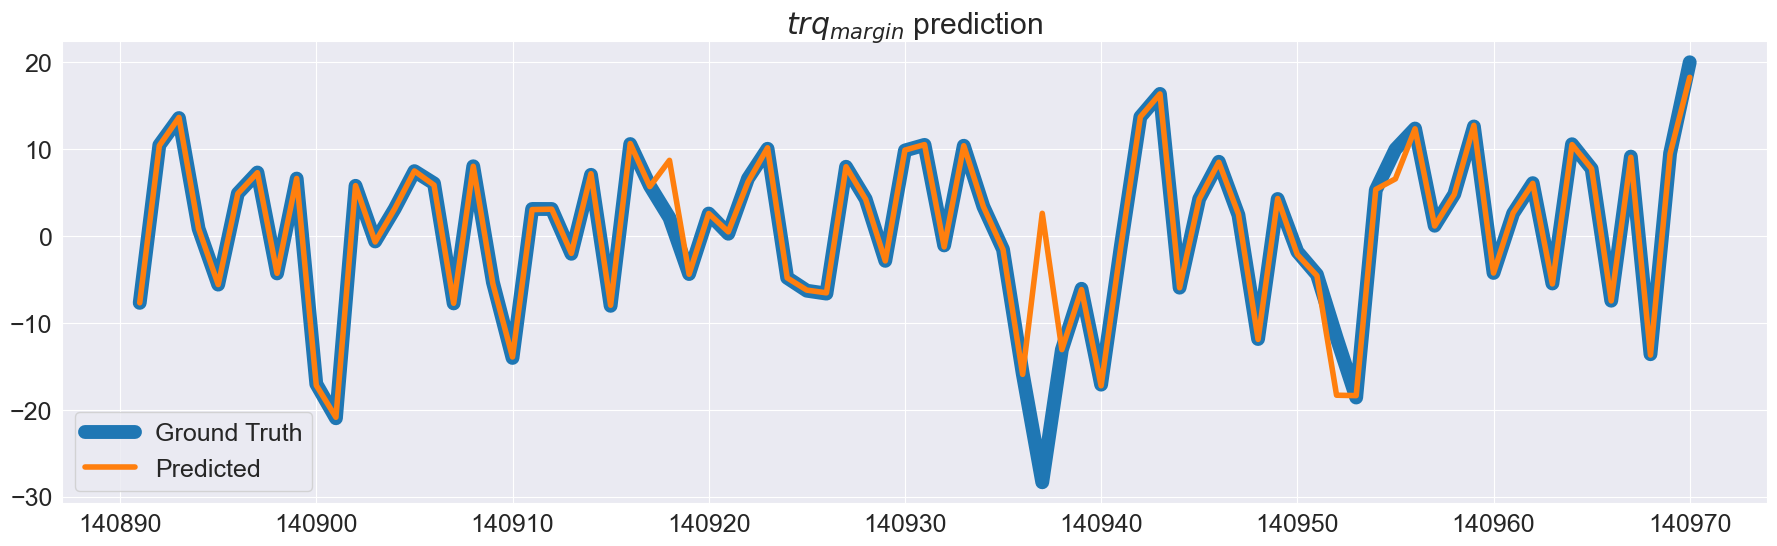

In [31]:
LENGTH = 80
i = random.randint(0, len(train_y) - LENGTH)
ax = train_y['trq_margin'][i:i + LENGTH].plot(figsize=(22, 6), linewidth=10, label='Ground Truth')
pred_train['trq_margin'][i:i + LENGTH].plot(ax=ax, linestyle='-', linewidth=4, label='Predicted')
ax.legend()
ax.set_title('$trq_{margin}$ prediction')

Note: in this plot, it's not evident the standard deviation. Smaller models tend to generate a visually better plot, even with a lower score. The more uncertain is the prediction, i.e. a large value of the standard deviation, the more the score will be penalized.

In [32]:
def score_rgr(pdf_type, pdf_args, true_target):
    # Extract the scipy model
    model = {'norm': stats.norm, 'cauchy': stats.cauchy}[pdf_type]

    # Calculate the score
    score = model.pdf(true_target, **pdf_args)

    # The following block of code generates the full PDF for potential normalization

    # Generate x values for plotting and integration
    n_points = 1000
    x = np.linspace(-100, 100, n_points)
    y = model.pdf(x, **pdf_args)

    # Verify the area under the curve using numerical integration
    area = simps(y, x)

    # Normalize the PDF if the area greater than 1
    if area > 1:
        score = score / area

    # Normalize score if the PDF max is greater than 1
    y_max = y.max()
    if y_max > 1:
        y = y / y_max
        score = score / y_max

    return score

Reducing $\sigma$ beyond
$
\boxed{\sigma = \frac{1}{\sqrt{2\pi}} \approx 0.3989}
$
doesn't increase the score!

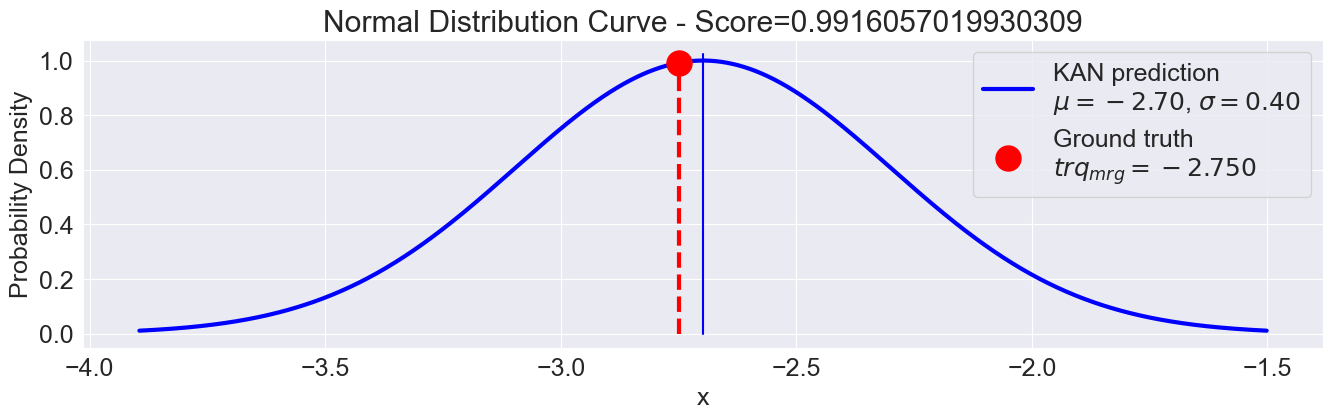

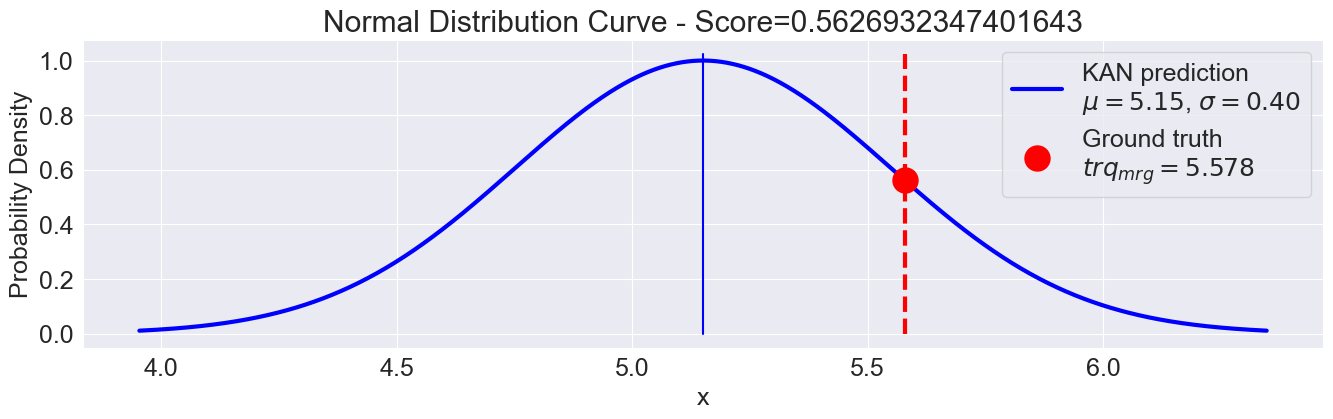

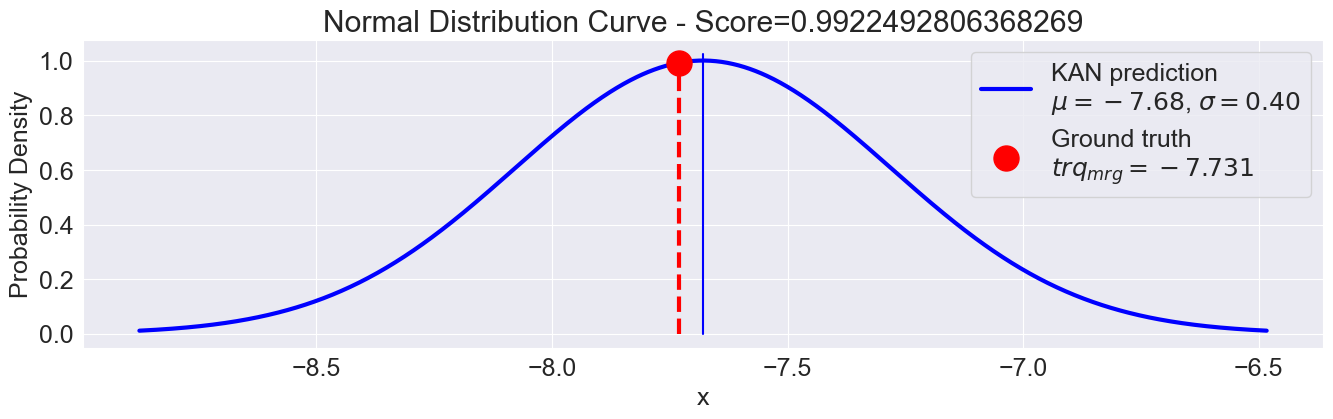

Mean score = 0.873366488331236


In [33]:
scores = []
for i in np.random.choice(len(pred_train), 2000, replace=False):
    mu, std = pred_train['trq_margin'][i], pred_train['trq_margin_std'][i]
    ground_truth = train_y['trq_margin'][i]

    x = np.linspace(mu - 3 * std, mu + 3 * std, 1000)
    pdf = stats.norm.pdf(x, mu, std)
    score = score_rgr("norm", {"loc": mu, "scale": std}, ground_truth)
    scores.append(score)

    if len(scores) < 4:
        fig, ax = plt.subplots(figsize=(16, 4))
        ax.plot(x, pdf, label=f'KAN prediction\n$\mu={mu:.2f}$, $\sigma={std:.2f}$', color='blue', linewidth=3)
        ax.add_line(Line2D([mu, mu], [0, pdf.max() * 1.025], linestyle='-', color='blue'))
        ax.add_line(
            Line2D([ground_truth, ground_truth], [0, pdf.max() * 1.025], linestyle='--', color='red', linewidth=3))
        ax.plot(ground_truth, stats.norm.pdf(ground_truth, mu, std), 'ro',
                label=f'Ground truth\n$trq_{"{mrg}"}={ground_truth:.3f}$', markersize=18)
        plt.title(f'Normal Distribution Curve - Score={score}')
        plt.xlabel('x')
        plt.ylabel('Probability Density')
        plt.legend()
        plt.show()
print(f"Mean score = {sum(scores) / len(scores)}")

The $trq_{margin}$ is the input to the classifier, so here we compute it from the predicted $trq_{target}$.
$$trq_{margin}=\left(\dfrac{trq_{measured}}{trq_{target}}-1 \right)\times 100$$

In [34]:
# 3s
pred_train.to_csv('predictions_train.csv', index=False)
pred_valid.to_csv('predictions_valid.csv', index=False)
pred_test.to_csv('predictions_test.csv', index=False)